<a href="https://colab.research.google.com/github/hemanthrajelangovan07-sudo/smoltalk-rlhf-pipeline/blob/main/1_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset, DatasetDict
import random

sft_raw = load_dataset("HuggingFaceTB/smoltalk", "all", split="train")
print(f"SmolTalk full size: {len(sft_raw):,} samples")
print(f"Features: {list(sft_raw.features.keys())}")
print(f"\nSample (first message):\n{sft_raw[0]['messages'][0]}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/all/train-00000-of-00009.parquet:   0%|          | 0.00/223M [00:00<?, ?B/s]

data/all/train-00001-of-00009.parquet:   0%|          | 0.00/223M [00:00<?, ?B/s]

data/all/train-00002-of-00009.parquet:   0%|          | 0.00/223M [00:00<?, ?B/s]

...

data/all/train-00008-of-00009.parquet:   0%|          | 0.00/224M [00:00<?, ?B/s]

data/all/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1043917 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/54948 [00:00<?, ? examples/s]

SmolTalk full size: 1,043,917 samples
Features: ['messages', 'source']

Sample (first message):
{'content': 'The function \\( g(x) \\) satisfies the functional equation\n\\[ g(x + y) = g(x) + g(y) \\]\nfor all real numbers \\( x \\) and \\( y \\), and it is given that \\( g(3) = 4 \\). Find \\( g(10) \\).', 'role': 'user'}


In [ ]:
def filter_sft_quality(example):
    """
    Remove low-quality samples that would hurt training.
    Criteria:
    1. Must have at least 2 messages (user + assistant)
    2. Assistant response must be >50 chars (not trivially short)
    3. Assistant response must be <2000 chars (avoid repetitive/bloated)
    4. No broken/empty messages
    """
    messages = example.get('messages', [])
    if len(messages) < 2:
        return False

    assistant_msgs = [m for m in messages if m['role'] == 'assistant']
    if not assistant_msgs:
        return False

    last_response = assistant_msgs[-1]['content']
    if not last_response or not isinstance(last_response, str):
        return False

    response_len = len(last_response.strip())
    return 50 < response_len < 2000

sft_filtered = sft_raw.filter(
    filter_sft_quality,
    num_proc=2,
    desc="Filtering SFT quality"
)
print(f"After quality filter: {len(sft_filtered):,} samples (from {len(sft_raw):,})")

random.seed(42)
N_SFT = 15_000
sft_dataset = sft_filtered.select(random.sample(range(len(sft_filtered)), min(N_SFT, len(sft_filtered))))
print(f"Final SFT dataset: {len(sft_dataset):,} samples")


Filtering SFT quality (num_proc=2):   0%|          | 0/1043917 [00:00<?, ? examples/s]

After quality filter: 760,122 samples (from 1,043,917)
Final SFT dataset: 15,000 samples


In [ ]:
import os

BASE_DIR = "/content"
os.makedirs(f"{BASE_DIR}/datasets", exist_ok=True)

sft_dataset.save_to_disk(f"{BASE_DIR}/datasets/sft_smoltalk_15k")
print(f"✅ SFT dataset saved: {BASE_DIR}/datasets/sft_smoltalk_15k")

Saving the dataset (0/1 shards):   0%|          | 0/15000 [00:00<?, ? examples/s]

✅ SFT dataset saved: /content/datasets/sft_smoltalk_15k


In [ ]:
simpo_raw = load_dataset("trl-lib/ultrafeedback_binarized", split="train")
print(f"UltraFeedback full size: {len(simpo_raw):,} pairs")

def filter_simpo_quality(example):
    """
    Filter preference pairs for quality:
    1. Score margin must be ≥ 1.0 (clear preference signal)
    2. Both responses must be non-empty
    3. Chosen must be longer than rejected by ≤ 3× (avoid length bias)
    """
    score_chosen = example.get('score_chosen', 0)
    score_rejected = example.get('score_rejected', 0)

    if (score_chosen - score_rejected) < 1.0:
        return False

    chosen_msgs = example.get('chosen', [])
    rejected_msgs = example.get('rejected', [])

    if not chosen_msgs or not rejected_msgs:
        return False

    def last_assistant(msgs):
        for m in reversed(msgs):
            if m.get('role') == 'assistant':
                return m.get('content', '')
        return ''

    chosen_text = last_assistant(chosen_msgs)
    rejected_text = last_assistant(rejected_msgs)

    if not chosen_text or not rejected_text:
        return False

    ratio = len(chosen_text) / max(len(rejected_text), 1)
    if ratio > 3.0 or ratio < 0.33:
        return False

    return True

simpo_filtered = simpo_raw.filter(filter_simpo_quality, num_proc=2, desc="Filtering SimPO quality")
print(f"After quality filter: {len(simpo_filtered):,} pairs")

N_SIMPO = 15_000
simpo_dataset = simpo_filtered.select(range(min(N_SIMPO, len(simpo_filtered))))
simpo_dataset.save_to_disk(f"{BASE_DIR}/datasets/simpo_ultrafeedback_15k")
print(f"✅ SimPO dataset saved")


README.md:   0%|          | 0.00/643 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/131M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.14M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/62135 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

UltraFeedback full size: 62,135 pairs


Filtering SimPO quality (num_proc=2):   0%|          | 0/62135 [00:00<?, ? examples/s]

After quality filter: 27,958 pairs


Saving the dataset (0/1 shards):   0%|          | 0/15000 [00:00<?, ? examples/s]

✅ SimPO dataset saved


In [ ]:
gsm8k = load_dataset("openai/gsm8k", "main", split="train")
print(f"GSM8K train: {len(gsm8k):,} problems")
print(f"Sample: {gsm8k[0]}")

def format_gsm8k_for_grpo(example):
    """Format GSM8K for GRPO: extract numeric answer for reward function."""
    import re
    answer_text = example['answer']
    match = re.search(r'####\s*([\d,\-]+)', answer_text)
    numeric_answer = match.group(1).replace(',', '') if match else None

    return {
        'prompt': [
            {'role': 'system', 'content': 'You are a precise math problem solver. Think step by step, then give your final answer as a number after "#### ".'},
            {'role': 'user', 'content': example['question']}
        ],
        'answer': numeric_answer,
        'full_solution': answer_text,
    }

grpo_dataset = gsm8k.map(format_gsm8k_for_grpo, desc="Formatting GSM8K")
grpo_dataset = grpo_dataset.filter(lambda x: x['answer'] is not None)
grpo_dataset.save_to_disk(f"{BASE_DIR}/datasets/grpo_gsm8k")
print(f"✅ GRPO dataset ready: {len(grpo_dataset):,} problems (all with numeric answers)")



GSM8K train: 7,473 problems
Sample: {'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?', 'answer': 'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72'}


Saving the dataset (0/1 shards):   0%|          | 0/7473 [00:00<?, ? examples/s]

✅ GRPO dataset ready: 7,473 problems (all with numeric answers)


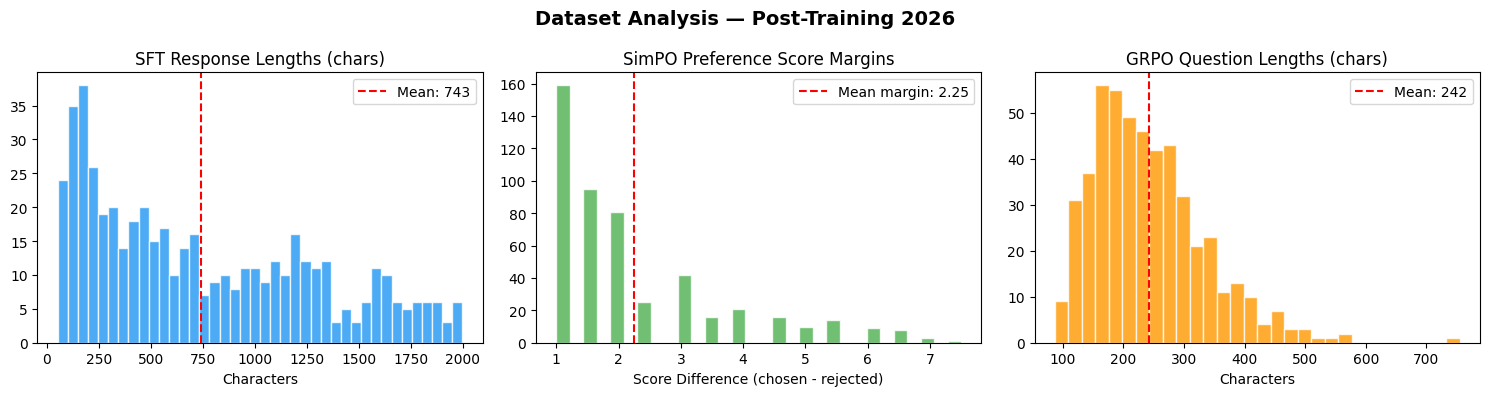

✅ EDA plot saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dataset Analysis — Post-Training 2026", fontsize=14, fontweight='bold')

sft_lengths = []
for ex in sft_dataset.select(range(500)):
    asst = [m for m in ex['messages'] if m['role'] == 'assistant']
    if asst:
        sft_lengths.append(len(asst[-1]['content']))

axes[0].hist(sft_lengths, bins=40, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].axvline(np.mean(sft_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(sft_lengths):.0f}')
axes[0].set_title("SFT Response Lengths (chars)")
axes[0].set_xlabel("Characters")
axes[0].legend()

margins = [ex['score_chosen'] - ex['score_rejected'] for ex in simpo_dataset.select(range(500))]
axes[1].hist(margins, bins=30, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1].axvline(np.mean(margins), color='red', linestyle='--', label=f'Mean margin: {np.mean(margins):.2f}')
axes[1].set_title("SimPO Preference Score Margins")
axes[1].set_xlabel("Score Difference (chosen - rejected)")
axes[1].legend()

gsm_lengths = [len(ex['question']) for ex in grpo_dataset.select(range(500))]
axes[2].hist(gsm_lengths, bins=30, color='#FF9800', alpha=0.8, edgecolor='white')
axes[2].axvline(np.mean(gsm_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(gsm_lengths):.0f}')
axes[2].set_title("GRPO Question Lengths (chars)")
axes[2].set_xlabel("Characters")
axes[2].legend()

plt.tight_layout()
os.makedirs(f"{BASE_DIR}/logs", exist_ok=True)
plt.savefig(f"{BASE_DIR}/logs/dataset_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ EDA plot saved")